In [4]:
import pandas as pd

In [5]:
beer_data = pd.read_csv(r"C:\Users\Lenovo\Downloads\Iowa_Liquor_Sales.csv",dtype={'Zip Code': 'str'})
beer_data

,Invoice/Item Number,Date,Store Number,Store Name,Address,City,Zip Code,Store Location,County Number,County,...,Item Number,Item Description,Pack,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Sale (Dollars),Volume Sold (Liters),Volume Sold (Gallons)
0,S29198800001,11/20/2015,2191,Keokuk Spirits,1013 MAIN,KEOKUK,52632,"1013 MAIN\nKEOKUK 52632\n(40.39978, -91.387531)",56.0,Lee,...,297,Templeton Rye w/Flask,6,750,$18.09,$27.14,6,$162.84,4.50,1.19
1,S29195400002,11/21/2015,2205,Ding's Honk And Holler,900 E WASHINGTON,CLARINDA,51632,"900 E WASHINGTON\nCLARINDA 51632\n(40.739238, ...",73.0,Page,...,297,Templeton Rye w/Flask,6,750,$18.09,$27.14,12,$325.68,9.00,2.38
2,S29050300001,11/16/2015,3549,Quicker Liquor Store,1414 48TH ST,FORT MADISON,52627,"1414 48TH ST\nFORT MADISON 52627\n(40.624226, ...",56.0,Lee,...,249,Disaronno Amaretto Cavalli Mignon 3-50ml Pack,20,150,$6.40,$9.60,2,$19.20,0.30,0.08
3,S28867700001,11/04/2015,2513,Hy-Vee Food Store #2 / Iowa City,812 S 1ST AVE,IOWA CITY,52240,812 S 1ST AVE\nIOWA CITY 52240\n,52.0,Johnson,...,237,Knob Creek w/ Crystal Decanter,3,1750,$35.55,$53.34,3,$160.02,5.25,1.39
4,S29050800001,11/17/2015,3942,Twin Town Liquor,104 HIGHWAY 30 WEST,TOLEDO,52342,"104 HIGHWAY 30 WEST\nTOLEDO 52342\n(41.985887,...",86.0,Tama,...,249,Disaronno Amaretto Cavalli Mignon 3-50ml Pack,20,150,$6.40,$9.60,2,$19.20,0.30,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12591072,INV-08368000074,10/31/2017,5423,Stammer Liquor Corp,615 2nd Ave,Sheldon,51201,"615 2nd Ave\nSheldon 51201\n(43.184614, -95.85...",71.0,OBRIEN,...,73802,FrappaChata Iced Coffee Blend,12,800,$8.00,$12.00,3,$12.00,2.40,0.63
12591073,INV-08368000075,10/31/2017,5423,Stammer Liquor Corp,615 2nd Ave,Sheldon,51201,"615 2nd Ave\nSheldon 51201\n(43.184614, -95.85...",71.0,OBRIEN,...,20375,Old Forester Statesman,6,750,$27.48,$41.22,2,$41.22,1.50,0.39
12591074,INV-08368000076,10/31/2017,5423,Stammer Liquor Corp,615 2nd Ave,Sheldon,51201,"615 2nd Ave\nSheldon 51201\n(43.184614, -95.85...",71.0,OBRIEN,...,20372,Old Forester 1897 Whisky Row Series,6,750,$24.98,$37.47,2,$37.47,1.50,0.39
12591075,INV-08368000077,10/31/2017,5423,Stammer Liquor Corp,615 2nd Ave,Sheldon,51201,"615 2nd Ave\nSheldon 51201\n(43.184614, -95.85...",71.0,OBRIEN,...,20369,Old Forester 1870 Whisky Row Series,6,750,$22.49,$33.74,2,$33.74,1.50,0.39


# <u> <strong> SKU Rationalization </strong> </u>

The top performing products and stores are best for SKU Rationalization as improvements on those specific asepcts will have an outsized benefit compared to optimization on less well-performing products/stores. The Pareto Principle (80/20) was tried to determine which beer products and stores account for vast majority of sales. However, the number of stores and products returned was unwieldy so the top 8 products and top 5 stores will be used as an alternative.

In [6]:
#Store Rationalization

sales_data = beer_data.groupby('Store Name')["Bottles Sold"].sum()
sorted_sales_data = sales_data.sort_values(ascending=False)

# Pandas Series with cumulative percentage to easily filter for the stores responsible for 80% of sales
cumulative_percentage_sales = sorted_sales_data.cumsum()/sorted_sales_data.sum()  
top_20_percent_stores = sorted_sales_data[cumulative_percentage_sales <= 0.80]
top_20_percent_stores

Store Name
Hy-Vee #3 / BDI / Des Moines           2759980
Central City 2                         1910141
Hy-Vee Wine and Spirits / Iowa City    1288319
Sam's Club 8162 / Cedar Rapids         1155985
Sam's Club 6344 / Windsor Heights      1089468
                                        ...   
Econ-o-mart / Columbus Junction          49068
Fareway Stores #561 / Waverly            49021
QUIK TRIP #503 / WINDSOR HEIGHTS         48949
Lake View Redemption Center              48712
Walgreens #07452 / Des Moines            48365
Name: Bottles Sold, Length: 488, dtype: int64

In [7]:
#Item Rationalization

item_data = beer_data.groupby('Item Description')["Bottles Sold"].sum()
sorted_item_data = item_data.sort_values(ascending=False)
cumulative_percentage_items = sorted_item_data.cumsum()/sorted_item_data.sum()
top_20_percent_items = sorted_item_data[cumulative_percentage_items <= 0.80]
top_20_percent_items


Item Description
Black Velvet                             5257235
Hawkeye Vodka                            3900198
Captain Morgan Spiced Rum                2618508
Five O'clock Vodka                       2557361
Jack Daniels Old #7 Black Lbl            1843032
                                          ...   
Montezuma Triple Sec                       87128
Paramount White Rum Traveler               85876
Paul Masson Peach Grande Amber Brandy      85758
Southern Comfort PET                       83676
Five Star Pet                              83157
Name: Bottles Sold, Length: 195, dtype: int64

In [8]:
top_8_items = sorted_item_data.head(8)
top_5_stores = sorted_sales_data.head(8)

beer_data['Date'] = pd.to_datetime(beer_data['Date'])
beer_data['Month_Year'] = beer_data['Date'].dt.strftime('%b-%Y')

# <u> <strong> Seasonality </strong> </u>


To better plan inventory levels, detecting seasonality trends is vital to see when inventory levels need to be higher and when costs can be saved by lowering inventory levels. Heatmaps are perfect for exploratory analysis but a more in-depth and mathematically vigorous analysis calls for statistical tools such as SARIMA (Seasonal Autoregressive Integrated Moving Average) 

# <u> <strong> Heatmap </strong> </u>


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

filtered_data_stores = beer_data[beer_data['Store Name'].isin(top_5_stores.index)]

# Average Monthly sales is desired.
# The dataframe must be grouped by Month and Year combinations instead of just Month to avoid combining sales from different years
month_year_grp_stores = filtered_data_stores.groupby(["Month_Year", "Store Name"])["Bottles Sold"].sum().reset_index()
month_year_grp_stores["DateTime"] = pd.to_datetime(month_year_grp_stores["Month_Year"], format="%b-%Y")
month_year_grp_stores["Month"] = month_year_grp_stores["DateTime"].dt.strftime("%B") 


<Axes: xlabel='Month', ylabel='Store Name'>

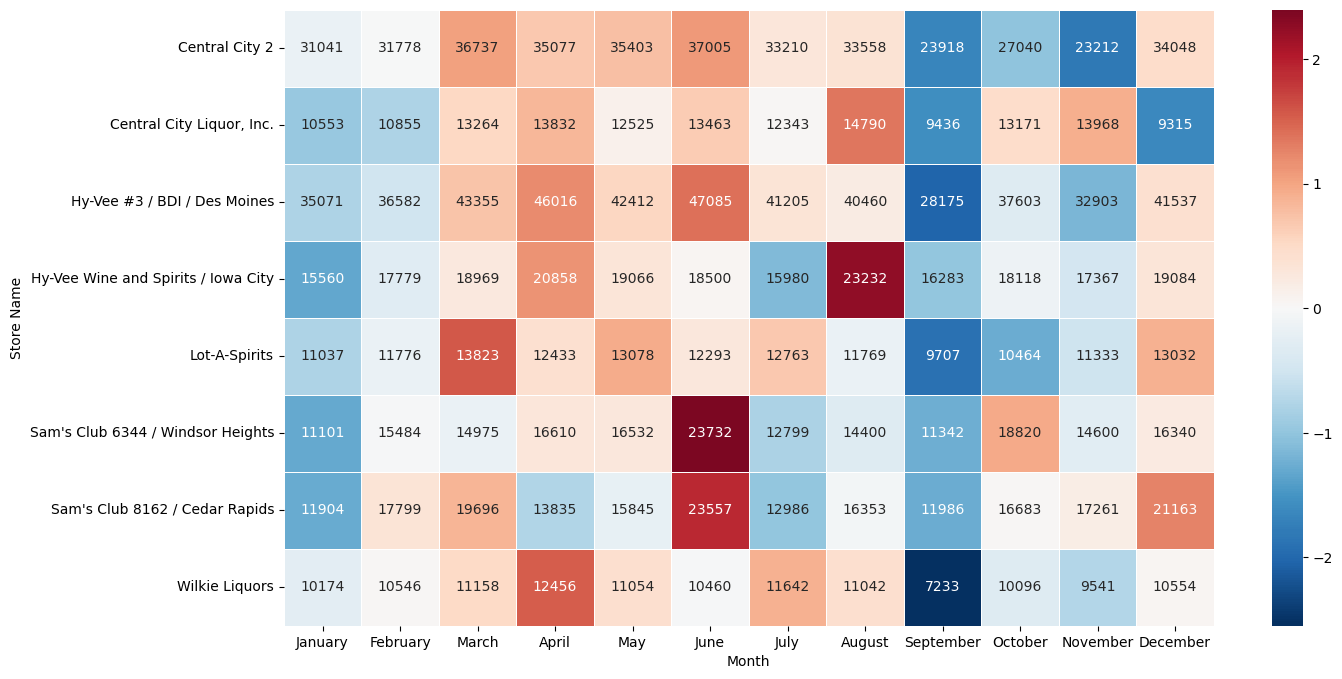

In [10]:
seasonality_store_data = month_year_grp_stores[['Store Name', 'Month','Bottles Sold']] 

heatmap_matrix_stores = seasonality_store_data.pivot_table(index="Store Name", columns="Month", values="Bottles Sold", aggfunc="mean")
# Manually sorting the months since seaborn defaults to alphabetical order when creating heatmaps
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
heatmap_matrix_stores = heatmap_matrix_stores.reindex(columns=month_order)

heatmap_z_store = heatmap_matrix_stores.sub(heatmap_matrix_stores.mean(axis=1), axis=0).div(heatmap_matrix_stores.std(axis=1), axis=0)
# heatmap_z_store normalizes each row in the heat map so it will correctly show "which months are relatively high/low for this item"

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_z_store, annot=heatmap_matrix_stores, fmt=".0f", cmap="RdBu_r", center=0, linewidths=0.5)


<Axes: xlabel='Month', ylabel='Item Description'>

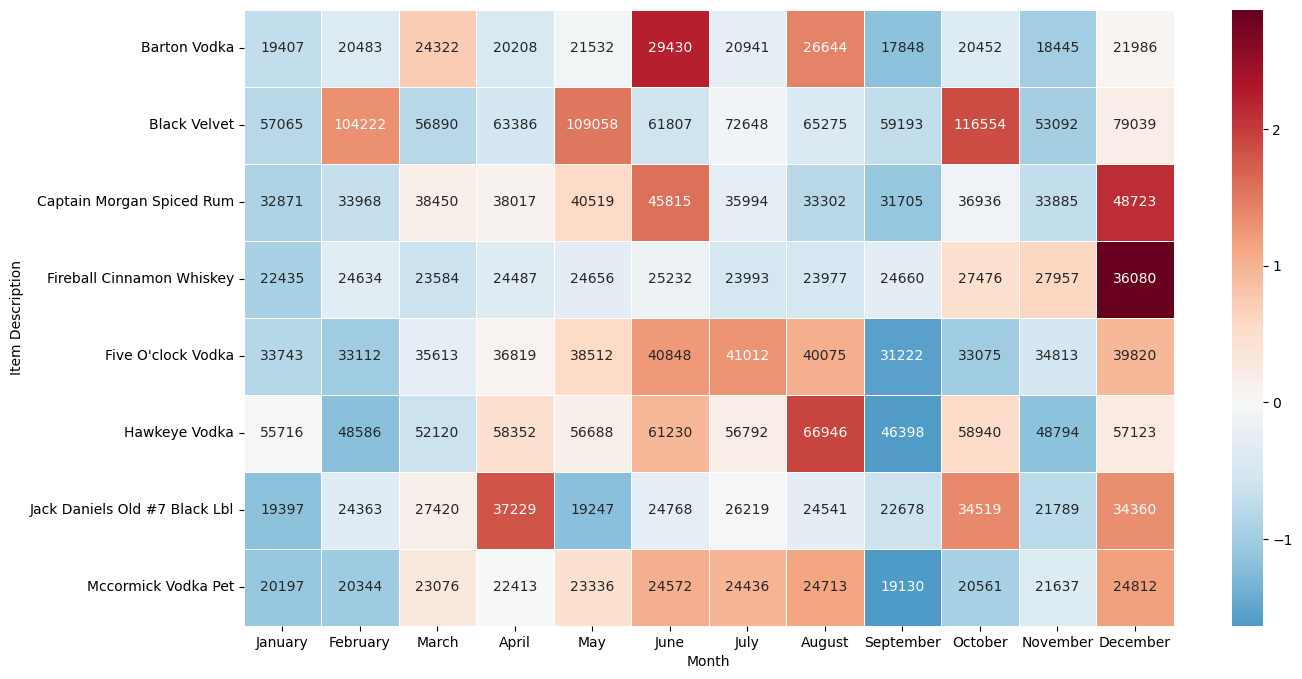

In [11]:
filtered_data_items = beer_data[beer_data['Item Description'].isin(top_8_items.index)]
month_year_grp_items = filtered_data_items.groupby(["Month_Year", "Item Description"])["Bottles Sold"].sum().reset_index()
month_year_grp_items["DateTime"] = pd.to_datetime(month_year_grp_items["Month_Year"], format="%b-%Y")
month_year_grp_items["Month"] = month_year_grp_items["DateTime"].dt.strftime("%B") 
seasonality_item_data = month_year_grp_items[['Item Description', 'Month','Bottles Sold']]

heatmap_matrix_item = seasonality_item_data.pivot_table(index="Item Description", columns="Month", values="Bottles Sold", aggfunc="mean")
heatmap_matrix_item = heatmap_matrix_item.reindex(columns=month_order)
heatmap_z_item = heatmap_matrix_item.sub(heatmap_matrix_item.mean(axis=1), axis=0).div(heatmap_matrix_item.std(axis=1), axis=0)

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_z_item, annot=heatmap_matrix_item, fmt=".0f", cmap="RdBu_r", center=0, linewidths=0.5)


# <u> <strong> SARIMA </strong> </u>


In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [62]:
import numpy as np

Five_O_Clock_Vodka_Data = beer_data[beer_data['Item Description'] == "Five O'clock Vodka"]

# log transformation done since the SARIMA model has no built-in business constraints (like stopping at zero). 
# The transformation prevents forecasts from becoming negative
log_monthly_vodka_data = Five_O_Clock_Vodka_Data.groupby("Month_Year")["Bottles Sold"].sum().apply(np.log1p) 


log_monthly_vodka_data.index = pd.to_datetime(log_monthly_vodka_data.index, format="%b-%Y")
log_monthly_vodka_data = log_monthly_vodka_data.asfreq("MS")
log_monthly_vodka_data = log_monthly_vodka_data.sort_index()


model = SARIMAX(log_monthly_vodka_data, order=(1,1,1), seasonal_order=(1,1,1,12))

results = model.fit()

print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       Bottles Sold   No. Observations:                   70
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -14.408
Date:                            Sat, 04 Jul 2026   AIC                             38.817
Time:                                    16:06:06   BIC                             49.032
Sample:                                01-01-2012   HQIC                            42.787
                                     - 10-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7508      3.676      0.204      0.838      -6.455       7.956
ma.L1         -0.7802      3.467   

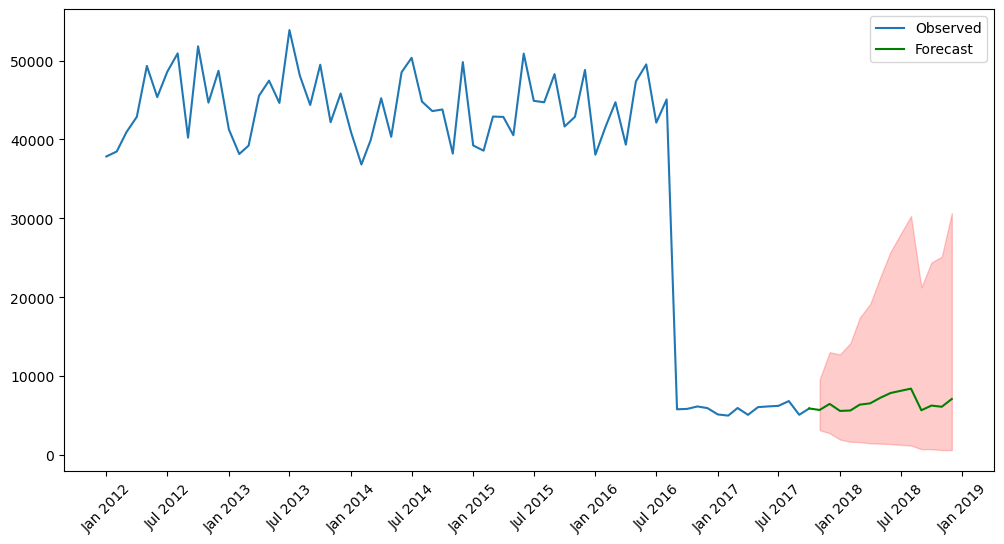

In [63]:
import matplotlib.dates as mdates

log_forecast = results.get_forecast(steps=14)
log_pred = log_forecast.predicted_mean
log_se = log_forecast.se_mean  # standard error of forecast

pred = np.expm1(log_pred + (log_se**2) / 2) # undoing the log transformation and applying analytic log-normal correction 
log_ci = log_forecast.conf_int()
ci = np.expm1(log_ci) # undoing the log transformation 

monthly_vodka_data = np.expm1(log_monthly_vodka_data) # reconverting to actual bottle counts


fig, ax = plt.subplots(figsize=(12,6))

# To connect historical line graph with forecast line graph on the plot
last_point = monthly_vodka_data.iloc[[-1]]
pred_connected = pd.concat([last_point, pred])

# Historical Data
ax.plot(monthly_vodka_data, label="Observed")

# Forecast
ax.plot(pred_connected, label="Forecast", color="green")

# Confidence intervals
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="red", alpha=0.2)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.legend()
plt.show()

# <u> <strong> Seasonality Analysis </strong> </u>

For both stores and items, December marks a particularly good month for sales. For Mccormick Vodka Pet and Five O'clock Vodka, May to August (~Summer Period) is especially good for sales. This increase in sales during the summer is generally seen in the top 5 stores as well.

However, the forecast for Five O'clock Vodka using SARIMA doesn't show strong seasonality so it is likely that the particular vodka doesn't have seasonality in sales. The large permanent drop in sales for Five O'clock Vodka on Jul 2016 is also worth investigating further (customer surveys, market analysis) to see what caused the steep drop in popularity
